In [3]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
pd.set_option('display.max_row', 111)
pd.set_option('display.max_column', 111)

In [5]:
df = pd.read_csv('/Users/nicolas/Desktop/scoring credit/archive-2/cs-training.csv')

In [6]:
df.head()

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


## EDA

### Goals :

- Understand our data as thoroughly as possible
- Develop an initial modeling strategy

### Shape Analysis
| Variable | Type | Description |
|---|---|---|
| SeriousDlqin2yrs | int (0/1) | **Target** — 1 if the borrower experienced a payment delay ≥ 90 days, 0 otherwise |
| RevolvingUtilizationOfUnsecuredLines | float | Utilization rate of revolving credit lines (credit card balances / total credit limits), excluding real estate and installment loans |
| age | int | Borrower's age (years) |
| NumberOfTime30-59DaysPastDueNotWorse | int | Number of times the borrower was 30-59 days past due (without going further) in the last 2 years |
| DebtRatio | float | Debt ratio = (debt payments + alimony + living costs) / gross monthly income |
| MonthlyIncome | float | Monthly income |
| NumberOfOpenCreditLinesAndLoans | int | Number of open loans and credit lines (e.g., car loan, mortgage) |
| NumberOfTimes90DaysLate | int | Number of times the borrower was ≥ 90 days late |
| NumberRealEstateLoansOrLines | int | Number of real estate/mortgage loans, including home equity lines of credit |
| NumberOfTime60-89DaysPastDueNotWorse | int | Number of times the borrower was 60-89 days past due (without going further) in the last 2 years |
| NumberOfDependents | int | Number of dependents in the household (excluding the borrower) |






- target variable: SeriousDlqin2yrs
- rows and columns: 150000, 12
- variable types: quantitative
- missing values analysis:
  - MonthlyIncome                           0.198207
  - NumberOfDependents                      0.026160


### In-depth Analysis
- Target visualization:
 - class 0  -->  93%
 - class 1  -->  7%
- Variable / Target relationship:
  - RevolvingUtilizationOfUnsecuredLines and age seem related to the target --> hypothesis to test. (The medians of both subgroups confirm this, as do the statistical tests.)
  - The default rate increases with RevolvingUtilizationOfUnsecuredLines
  - The default rate decreases with age
  - The default rate increases with NumberOfTime30-59DaysPastDueNotWorse and NumberOfTimes90DaysLate
  - 10% of people between 0 and 33 years old defaulted.
  - 60% of people with NumberOfTimes90DaysLate = 4 defaulted.
  - NumberOfTime60-89DaysPastDueNotWorse is also discriminative.
- Correlation Features / Target:
 - NumberOfTime30-59DaysPastDueNotWorse    0.125587
 - NumberOfTimes90DaysLate                 0.117175
 - age                                    -0.115386 (This is what we see on the chart: as age decreases, default increases.)

### Preprocessing Strategy


### 1. Missing Values

| Variable | Strategy | Detail |
|---|---|---|
| `MonthlyIncome` | Missing flag | `MonthlyIncome_missing` (1 if NaN, 0 otherwise), created **before** imputation |
| `MonthlyIncome` | Imputation | Global median (robust to strong skew). Could be refined with a group-wise median (e.g. by `age` bracket) later if needed |
| `NumberOfDependents` | Missing flag | `NumberOfDependents_missing` (optional, low stakes given the low NaN rate) |
| `NumberOfDependents` | Imputation | Median (≈ mode, distribution heavily concentrated on 0) |


### 2. Outliers

| Variable | Problem identified | Strategy | Detail |
|---|---|---|---|
| `RevolvingUtilizationOfUnsecuredLines` | "Normal" outlier — supposed to be a rate ≤ 1, but some values reach into the thousands | Winsorizing (cap) | Clip at the 99th percentile learned on the train set (threshold ≈ 1.09), applied as-is to the test set |
| `DebtRatio` | "Normal" outlier — ratio that explodes when `MonthlyIncome` is small (division by a small number) | Winsorizing (cap) | Clip at the 99th percentile learned on the train set (threshold ≈ 4977), applied as-is to the test set |
| `NumberOfTime30-59DaysPastDueNotWorse`, `NumberOfTimes90DaysLate`, `NumberOfTime60-89DaysPastDueNotWorse` | Sentinel codes 96/98 — known data-entry errors, not real delinquency counts | Flag + replacement | `_sentinel` column (1 if value == 96 or 98) created before replacement; value replaced by the median of valid train values |

**Why not handle both cases the same way?**
Capping the sentinel codes (like group A) would bring 96/98 down to a plausible value (e.g. 5-6 delinquencies), which would fabricate false information — the model would believe the client was seriously delinquent, when it's actually a data-entry error unrelated to real payment behavior. Hence the separate treatment: capping for true outliers, flag + neutral replacement for error codes.


### 3. Log-transform

| Variable | Observation | Strategy | Detail |
|---|---|---|---|
| `MonthlyIncome` | Very skewed distribution (income concentrated at the low end + long tail) | `log1p` | Resulting distribution is near-normal (well-formed bell curve) — the log works as expected |
| `DebtRatio` | Very skewed + bimodal distribution after log | `log1p` | The log reduces skew well for the "known income" population, but reveals an abnormal second peak |

**Why the log alone isn't enough for `DebtRatio`**

After log1p, `DebtRatio_log` shows two distinct peaks (verified via `groupby('MonthlyIncome_missing')`):
- `MonthlyIncome_missing == 0` (96,325 rows): median ≈ 0.26, low and tightly clustered values → genuine, coherent debt/income ratio.
- `MonthlyIncome_missing == 1` (23,675 rows): median ≈ 7.06, values clustered near the cap (8.51 = log1p of the 4977 cap) → artificially inflated values, not a real ratio.


### Shape Analysis

In [7]:
df = df.copy()

In [8]:
df.shape

(150000, 12)

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 12 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   Unnamed: 0                            150000 non-null  int64  
 1   SeriousDlqin2yrs                      150000 non-null  int64  
 2   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 3   age                                   150000 non-null  int64  
 4   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 5   DebtRatio                             150000 non-null  float64
 6   MonthlyIncome                         120269 non-null  float64
 7   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 8   NumberOfTimes90DaysLate               150000 non-null  int64  
 9   NumberRealEstateLoansOrLines          150000 non-null  int64  
 10  NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 11  NumberOfDep

In [10]:
df.describe()

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,1.202690e+05,150000.000000,150000.000000,150000.000000,150000.000000,146076.000000
mean,75000.500000,0.066840,6.048438,52.295207,0.421033,353.005076,6.670221e+03,8.452760,0.265973,1.018240,0.240387,0.757222
std,43301.414527,0.249746,249.755371,14.771866,4.192781,2037.818523,1.438467e+04,5.145951,4.169304,1.129771,4.155179,1.115086
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,37500.750000,0.000000,0.029867,41.000000,0.000000,0.175074,3.400000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,75000.500000,0.000000,0.154181,52.000000,0.000000,0.366508,5.400000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,112500.250000,0.000000,0.559046,63.000000,0.000000,0.868254,8.249000e+03,11.000000,0.000000,2.000000,0.000000,1.000000
max,150000.000000,1.000000,50708.000000,109.000000,98.000000,329664.000000,3.008750e+06,58.000000,98.000000,54.000000,98.000000,20.000000


<Axes: >

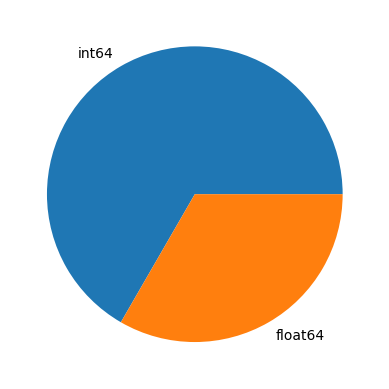

In [11]:
df.dtypes.value_counts().plot.pie()

<Axes: >

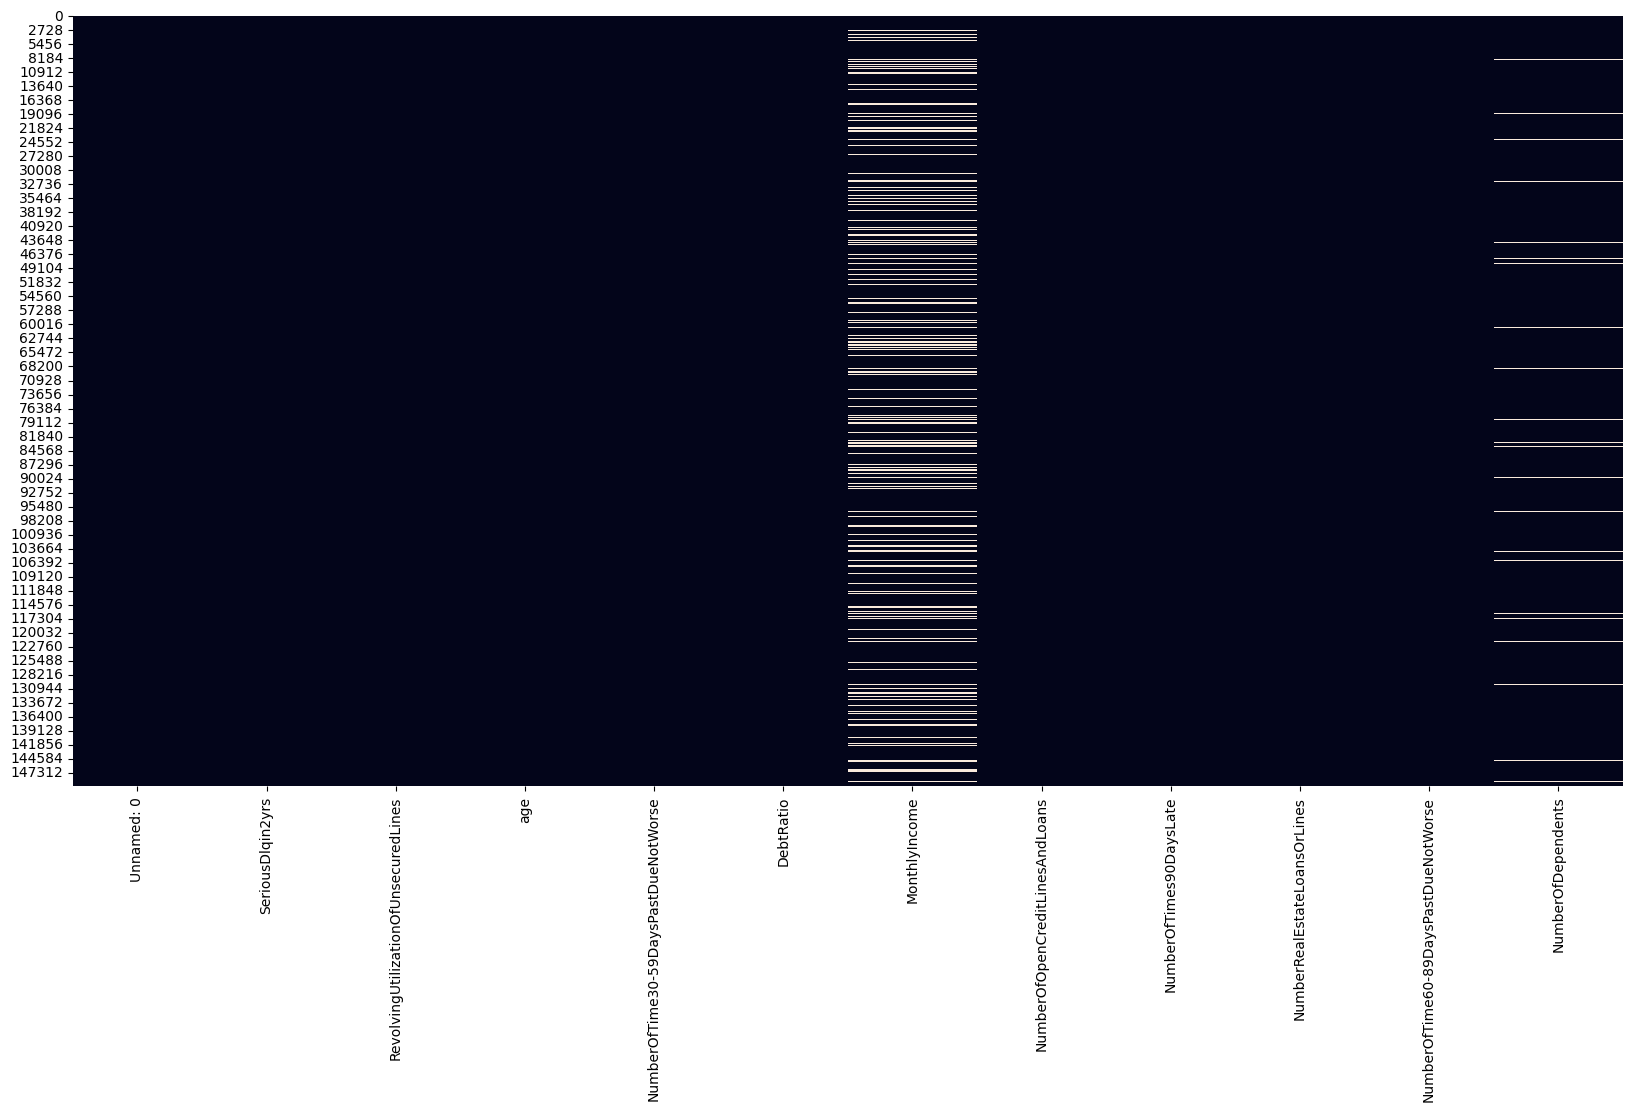

In [12]:
plt.figure(figsize=(20,10))
sns.heatmap(df.isna(), cbar=False)

In [13]:
(df.isna().sum()/df.shape[0]).sort_values(ascending=False)

MonthlyIncome                           0.198207
NumberOfDependents                      0.026160
Unnamed: 0                              0.000000
SeriousDlqin2yrs                        0.000000
age                                     0.000000
RevolvingUtilizationOfUnsecuredLines    0.000000
DebtRatio                               0.000000
NumberOfTime30-59DaysPastDueNotWorse    0.000000
NumberOfOpenCreditLinesAndLoans         0.000000
NumberOfTimes90DaysLate                 0.000000
NumberRealEstateLoansOrLines            0.000000
NumberOfTime60-89DaysPastDueNotWorse    0.000000
dtype: float64

### In-depth Analysis


### Initial Visualization - Removing Unnecessary Columns


In [14]:
df = df.drop('Unnamed: 0', axis=1)

### Examining the Target Column


In [15]:
df['SeriousDlqin2yrs'].value_counts(normalize=True)

SeriousDlqin2yrs
0    0.93316
1    0.06684
Name: proportion, dtype: float64

### Histograms of Continuous Variables


In [16]:
continuous_features = ['NumberOfOpenCreditLinesAndLoans']

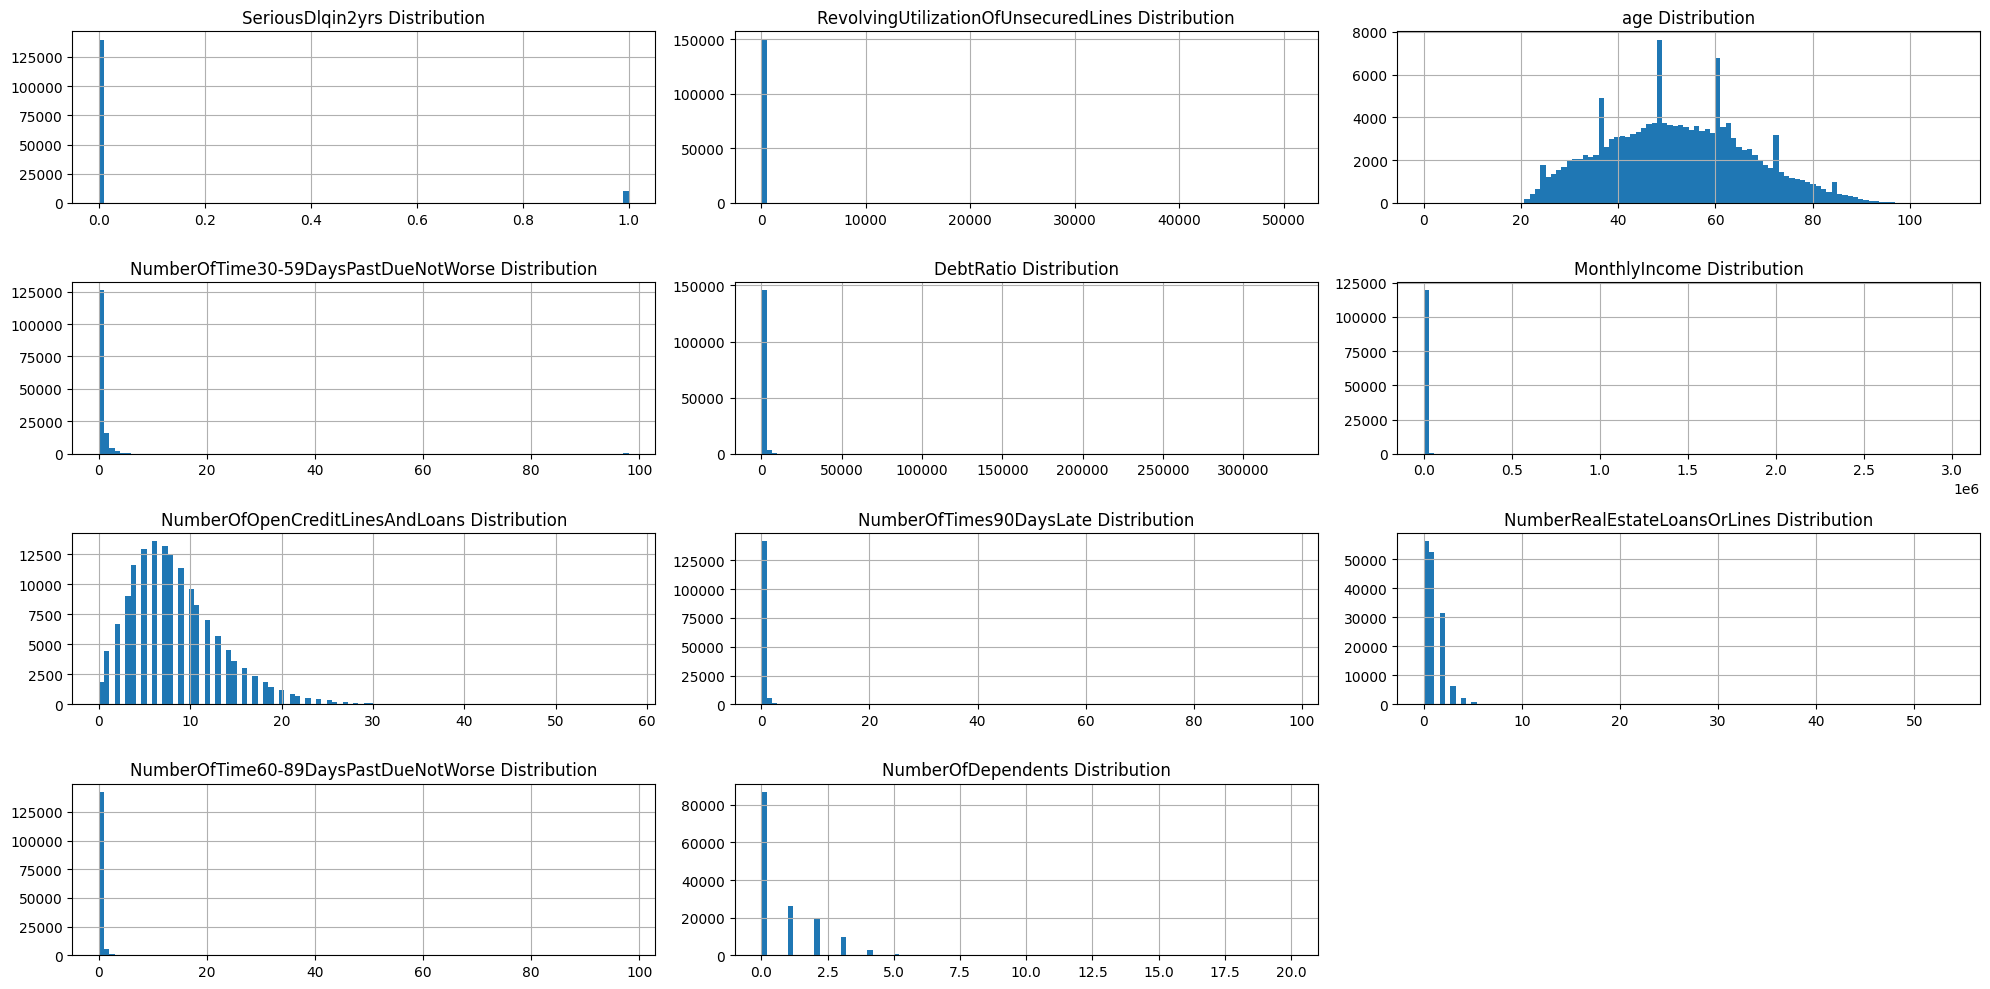

In [17]:
def draw_histograms(df, variables, n_rows, n_cols):
    fig=plt.figure(figsize=(20, 10))
    for i, var_name in enumerate(variables):
        ax=fig.add_subplot(n_rows,n_cols,i+1)
        df[var_name].hist(bins=100,ax=ax)
        ax.set_title(var_name+" Distribution")

    fig.tight_layout()  
    plt.show()


draw_histograms(df, df.columns, 4, 3)

## Bivariate Analysis (features vs target)

### Objective
- See how well each feature discriminates between the two classes of `SeriousDlqin2yrs`
- Spot outliers that distort the reading


In [18]:
target = 'SeriousDlqin2yrs'
continuous_features = ['RevolvingUtilizationOfUnsecuredLines', 'age', 'DebtRatio', 'MonthlyIncome']
discrete_features = ['NumberOfTime30-59DaysPastDueNotWorse', 'NumberOfOpenCreditLinesAndLoans',
                      'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines',
                      'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents']

### Distribution of Continuous Variables by Class


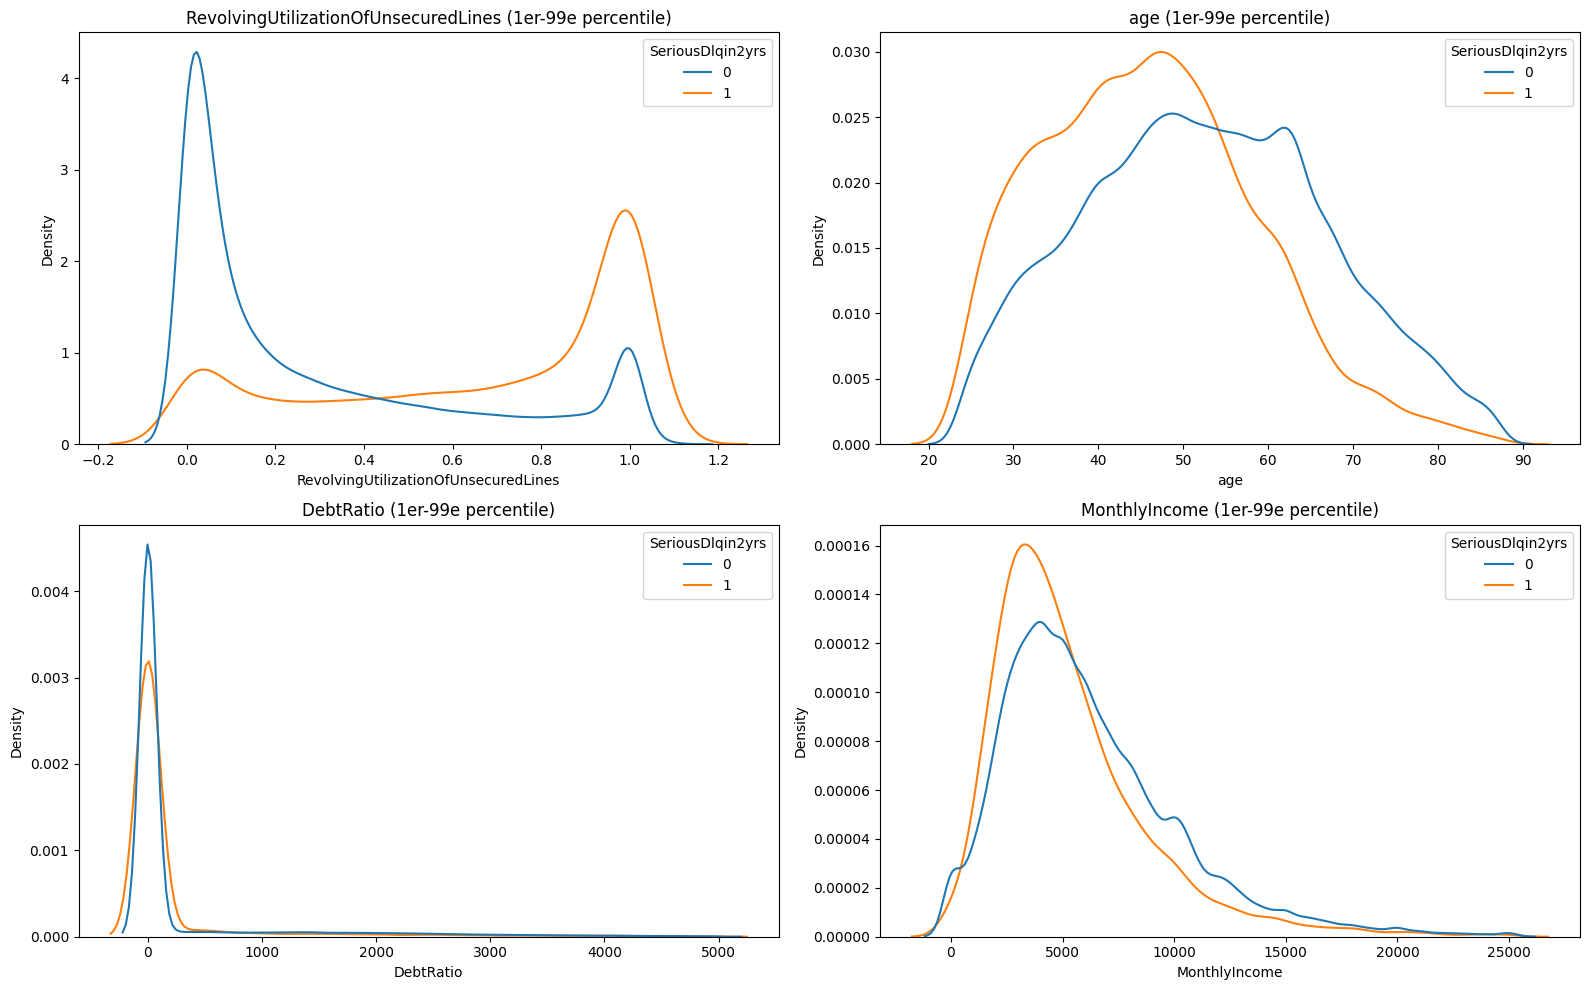

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
for ax, col in zip(axes.flatten(), continuous_features):
    low, high = df[col].quantile([0.01, 0.99])
    subset = df[df[col].between(low, high)]
    sns.kdeplot(data=subset, x=col, hue=target, common_norm=False, ax=ax)
    ax.set_title(f'{col} (1er-99e percentile)')
fig.tight_layout()
plt.show()

### Default Rate by Variable


In [20]:
def target_rate_by_feature(data, col, target=target, max_categories=20, q=10):
    sub = data[[col, target]].dropna()
    if sub[col].nunique() <= max_categories:
        cap = sub[col].quantile(0.995)
        capped = sub[col].clip(upper=cap)
        grouped = sub.assign(**{col: capped}).groupby(col)[target].agg(['mean', 'count'])
    else:
        bins = pd.qcut(sub[col], q=q, duplicates='drop')
        grouped = sub.groupby(bins, observed=True)[target].agg(['mean', 'count'])
    return grouped


def plot_target_rate(data, features, n_cols=3):
    n_rows = -(-len(features) // n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4 * n_rows))
    axes = axes.flatten()
    for ax, col in zip(axes, features):
        grouped = target_rate_by_feature(data, col)
        grouped['mean'].plot.bar(ax=ax, color='steelblue')
        ax.set_title(col)
        ax.set_ylabel('Taux de défaut')
        ax.tick_params(axis='x', rotation=45)
    for ax in axes[len(features):]:
        ax.axis('off')
    fig.tight_layout()
    plt.show()

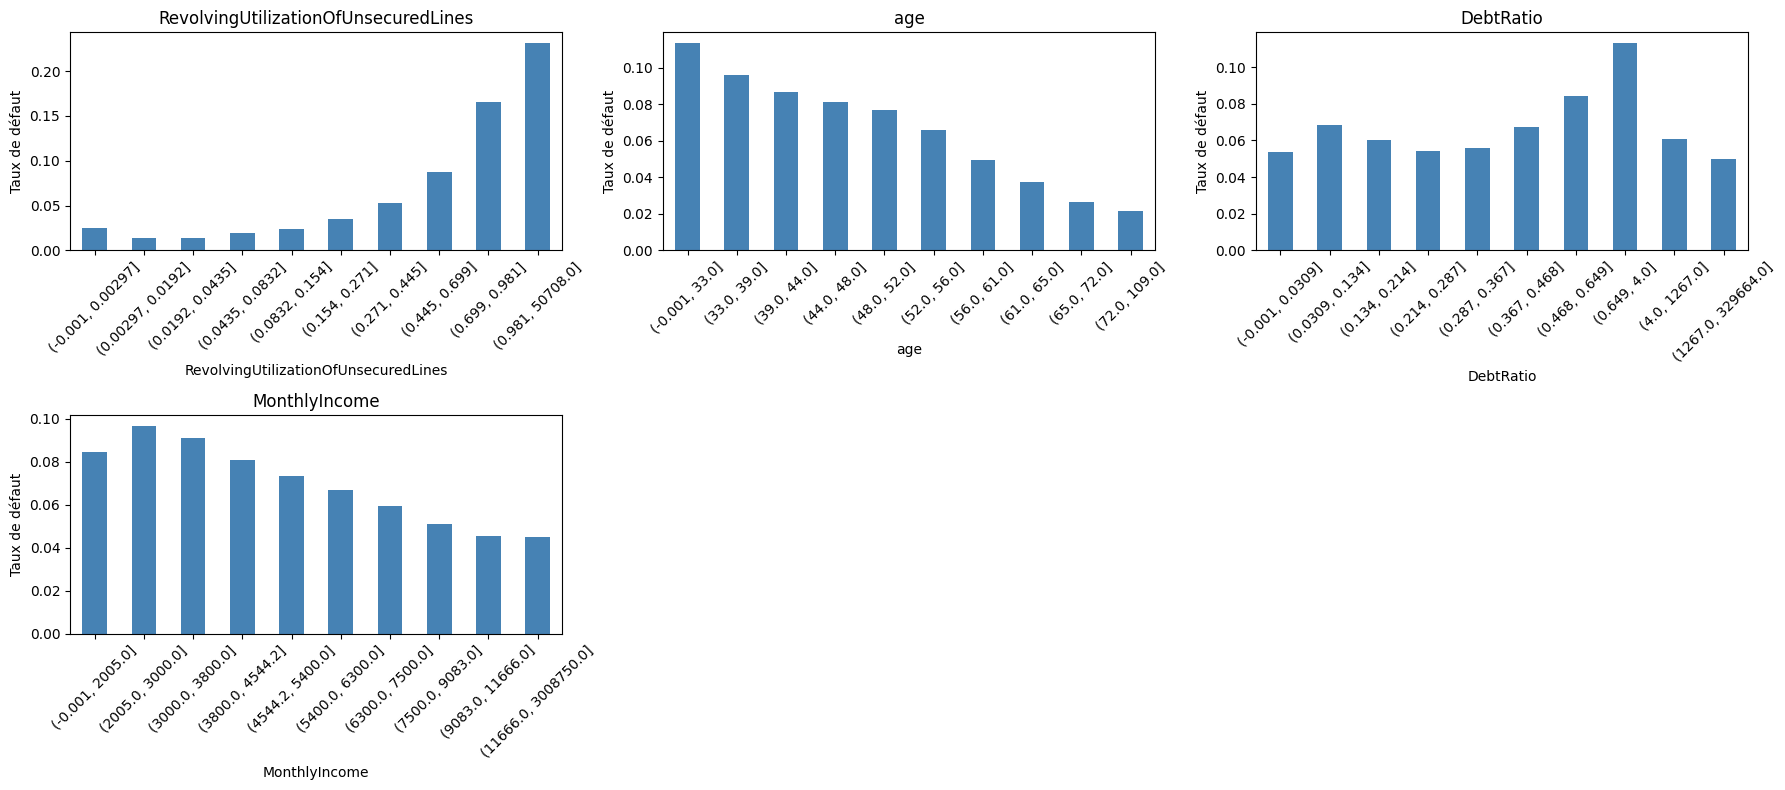

In [21]:
plot_target_rate(df, continuous_features)

In [22]:
from scipy import stats

for col in ["age", "RevolvingUtilizationOfUnsecuredLines"]:
    g0 = df.loc[df["SeriousDlqin2yrs"] == 0, col].dropna()
    g1 = df.loc[df["SeriousDlqin2yrs"] == 1, col].dropna()

    # Mann-Whitney U (non-paramétrique)
    u_stat, p_mw = stats.mannwhitneyu(g0, g1, alternative="two-sided")

    # Welch t-test (paramétrique, variances inégales)
    t_stat, p_t = stats.ttest_ind(g0, g1, equal_var=False)

    # Taille d'effet Cohen's d
    pooled_std = ((g0.std()**2 + g1.std()**2) / 2) ** 0.5
    cohens_d = (g1.mean() - g0.mean()) / pooled_std


    print(f"--- {col} ---")
    print(f"médiane non-défaut={g0.median():.3f} | médiane défaut={g1.median():.3f}")
    print(f"Mann-Whitney p={p_mw:.2e} | Welch t-test p={p_t:.2e} | Cohen's d={cohens_d:.3f}")


--- age ---
médiane non-défaut=52.000 | médiane défaut=45.000
Mann-Whitney p=0.00e+00 | Welch t-test p=0.00e+00 | Cohen's d=-0.492
--- RevolvingUtilizationOfUnsecuredLines ---
médiane non-défaut=0.133 | médiane défaut=0.839
Mann-Whitney p=0.00e+00 | Welch t-test p=2.25e-01 | Cohen's d=-0.009


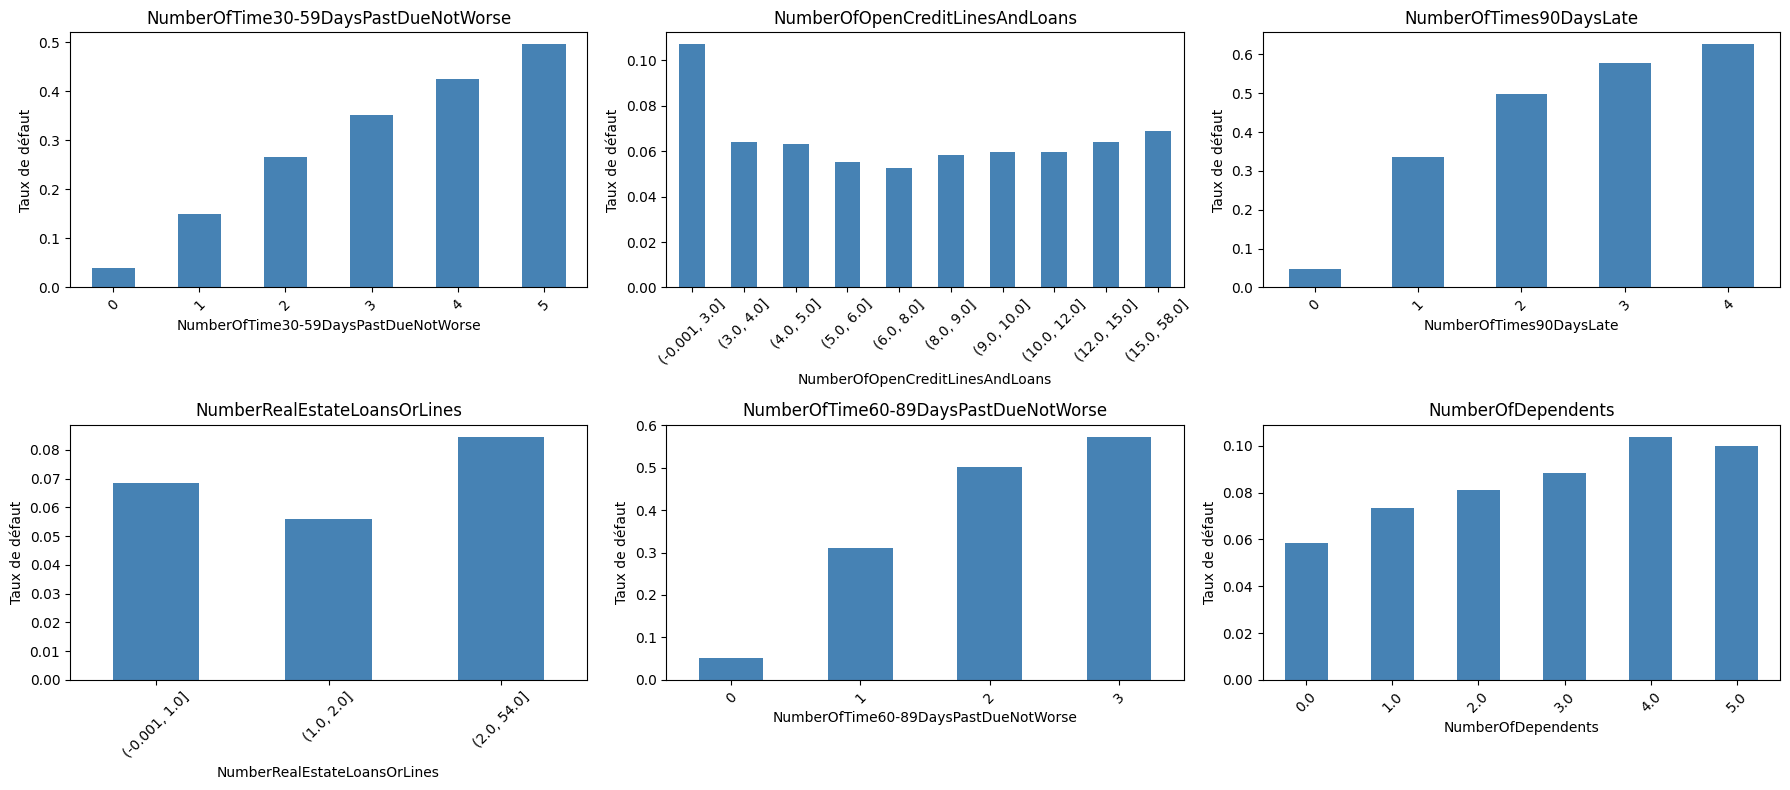

In [23]:
plot_target_rate(df, discrete_features)

In [24]:
df[df.RevolvingUtilizationOfUnsecuredLines > 2].shape[0]

371

### Correlation with the Target


In [25]:
corr_target = df.corr(numeric_only=True)[target].drop(target).sort_values(key=abs, ascending=False)
corr_target

NumberOfTime30-59DaysPastDueNotWorse    0.125587
NumberOfTimes90DaysLate                 0.117175
age                                    -0.115386
NumberOfTime60-89DaysPastDueNotWorse    0.102261
NumberOfDependents                      0.046048
NumberOfOpenCreditLinesAndLoans        -0.029669
MonthlyIncome                          -0.019746
DebtRatio                              -0.007602
NumberRealEstateLoansOrLines           -0.007038
RevolvingUtilizationOfUnsecuredLines   -0.001802
Name: SeriousDlqin2yrs, dtype: float64

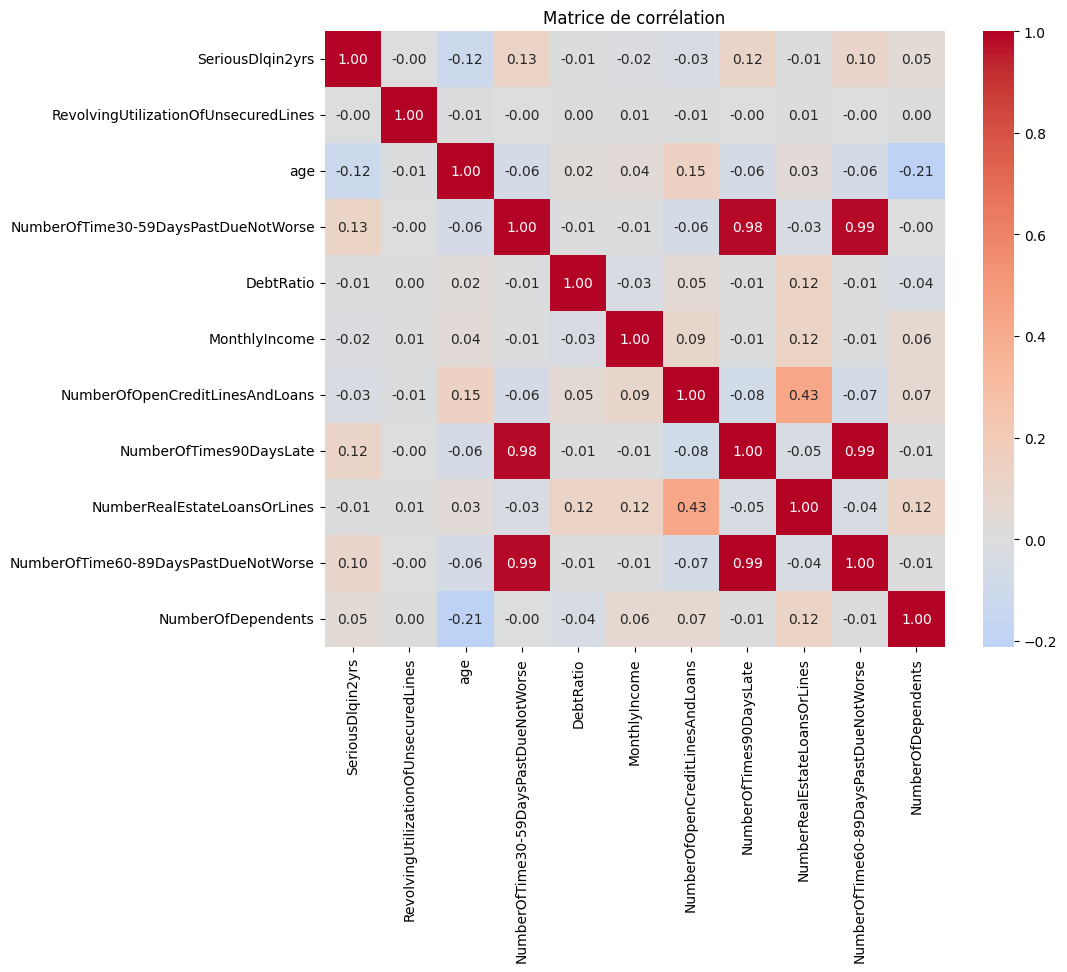

In [26]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Matrice de corrélation')
plt.show()

## Preprocessing

In [27]:
df = df.copy()

### 1. train-test split

In [28]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['SeriousDlqin2yrs'])
y = df['SeriousDlqin2yrs']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [29]:
y_test.value_counts(normalize=True)

SeriousDlqin2yrs
0    0.933167
1    0.066833
Name: proportion, dtype: float64

In [30]:
y_train.value_counts(normalize=True)

SeriousDlqin2yrs
0    0.933158
1    0.066842
Name: proportion, dtype: float64

### 2. Final Pipeline

In [ ]:
import numpy as np
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.compose import ColumnTransformer


def replace_sentinels(X):
    return np.where(np.isin(X, [96, 98]), np.nan, X)

def sentinel_pipeline():
    return make_pipeline(
        FunctionTransformer(replace_sentinels, feature_names_out="one-to-one"),
        SimpleImputer(strategy="median", add_indicator=True),  # ajoute le flag automatiquement
        StandardScaler()
    )



class Winsorizer(BaseEstimator, TransformerMixin):
    def __init__(self, quantile=0.99):
        self.quantile = quantile

    def fit(self, X, y=None):
        self.caps_ = np.nanquantile(np.asarray(X, dtype=float), self.quantile, axis=0)
        return self

    def transform(self, X):
        return np.clip(np.asarray(X, dtype=float), a_min=None, a_max=self.caps_)

    def get_feature_names_out(self, input_features=None):
        return np.asarray(input_features)

def revolving_pipeline():
    return make_pipeline(Winsorizer(quantile=0.99), StandardScaler())



class DebtRatioIncomeTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, debt_ratio_quantile=0.99):
        self.debt_ratio_quantile = debt_ratio_quantile

    def fit(self, X, y=None):
        X = np.asarray(X, dtype=float)
        debt_ratio, income = X[:, 0], X[:, 1]

        self.debt_ratio_cap_ = np.nanquantile(debt_ratio, self.debt_ratio_quantile)
        self.income_median_ = np.nanmedian(income)

        missing_income = np.isnan(income)
        debt_ratio_log = np.log1p(np.clip(debt_ratio, None, self.debt_ratio_cap_))
        self.debt_ratio_log_median_known_ = np.median(debt_ratio_log[~missing_income])
        return self

    def transform(self, X):
        X = np.asarray(X, dtype=float)
        debt_ratio, income = X[:, 0], X[:, 1]

        missing_income = np.isnan(income).astype(int)

        debt_ratio_log = np.log1p(np.clip(debt_ratio, None, self.debt_ratio_cap_))
        debt_ratio_log = np.where(missing_income == 1, self.debt_ratio_log_median_known_, debt_ratio_log)

        income_log = np.log1p(np.where(np.isnan(income), self.income_median_, income))

        return np.column_stack([debt_ratio_log, income_log, missing_income])

    def get_feature_names_out(self, input_features=None):
        return np.array(["DebtRatio_log", "MonthlyIncome_log", "MonthlyIncome_missing"])

def debt_income_pipeline():
    return make_pipeline(DebtRatioIncomeTransformer(), StandardScaler())



default_num_pipeline = make_pipeline(
    SimpleImputer(strategy="median", add_indicator=True),
    StandardScaler()
)


preprocessing = ColumnTransformer([
    ("late_30_59", sentinel_pipeline(), ["NumberOfTime30-59DaysPastDueNotWorse"]),
    ("late_60_89", sentinel_pipeline(), ["NumberOfTime60-89DaysPastDueNotWorse"]),
    ("late_90",    sentinel_pipeline(), ["NumberOfTimes90DaysLate"]),
    ("revolving",  revolving_pipeline(), ["RevolvingUtilizationOfUnsecuredLines"]),
    ("debt_income", debt_income_pipeline(), ["DebtRatio", "MonthlyIncome"]),
], remainder=default_num_pipeline)  # colonnes restantes : age, NumberOfOpenCreditLinesAndLoans,
                                     # NumberRealEstateLoansOrLines, NumberOfDependents


X_train_prepared = preprocessing.fit_transform(X_train)
X_test_prepared = preprocessing.transform(X_test)

print(preprocessing.get_feature_names_out())
print(X_train_prepared.shape)


['late_30_59__NumberOfTime30-59DaysPastDueNotWorse'
 'late_30_59__missingindicator_NumberOfTime30-59DaysPastDueNotWorse'
 'late_60_89__NumberOfTime60-89DaysPastDueNotWorse'
 'late_60_89__missingindicator_NumberOfTime60-89DaysPastDueNotWorse'
 'late_90__NumberOfTimes90DaysLate'
 'late_90__missingindicator_NumberOfTimes90DaysLate'
 'revolving__RevolvingUtilizationOfUnsecuredLines'
 'debt_income__DebtRatio_log' 'debt_income__MonthlyIncome_log'
 'debt_income__MonthlyIncome_missing' 'remainder__age'
 'remainder__NumberOfOpenCreditLinesAndLoans'
 'remainder__NumberRealEstateLoansOrLines' 'remainder__NumberOfDependents'
 'remainder__missingindicator_NumberOfDependents']
(120000, 15)


### Select and Train a model

### 1. Regression Logistic

In [32]:
from sklearn.linear_model import LogisticRegression

In [33]:
LR = make_pipeline(preprocessing, LogisticRegression(
        random_state=42,
        max_iter=1000,        # évite les warnings de non-convergence
        class_weight='balanced'  # compense le déséquilibre 93%/7%
    ))

In [34]:
LR.fit(X_train, y_train)

,steps,"[('columntransformer', ...), ('logisticregression', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('late_30_59', ...), ('late_60_89', ...), ...]"
,remainder,Pipeline(step...ardScaler())])
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [35]:
from sklearn.metrics import (
    roc_auc_score, RocCurveDisplay,
    average_precision_score, PrecisionRecallDisplay,
    classification_report, ConfusionMatrixDisplay
)

In [36]:
y_proba = LR.predict_proba(X_test)[:, 1]
y_pred = LR.predict(X_test)

print(f"ROC AUC                    : {roc_auc_score(y_test, y_proba):.4f}")
print(f"Average Precision (PR AUC) : {average_precision_score(y_test, y_proba):.4f}")
print()
print(classification_report(y_test, y_pred))

ROC AUC                    : 0.8603
Average Precision (PR AUC) : 0.3890

              precision    recall  f1-score   support

           0       0.98      0.81      0.88     27995
           1       0.22      0.75      0.34      2005

    accuracy                           0.80     30000
   macro avg       0.60      0.78      0.61     30000
weighted avg       0.93      0.80      0.85     30000



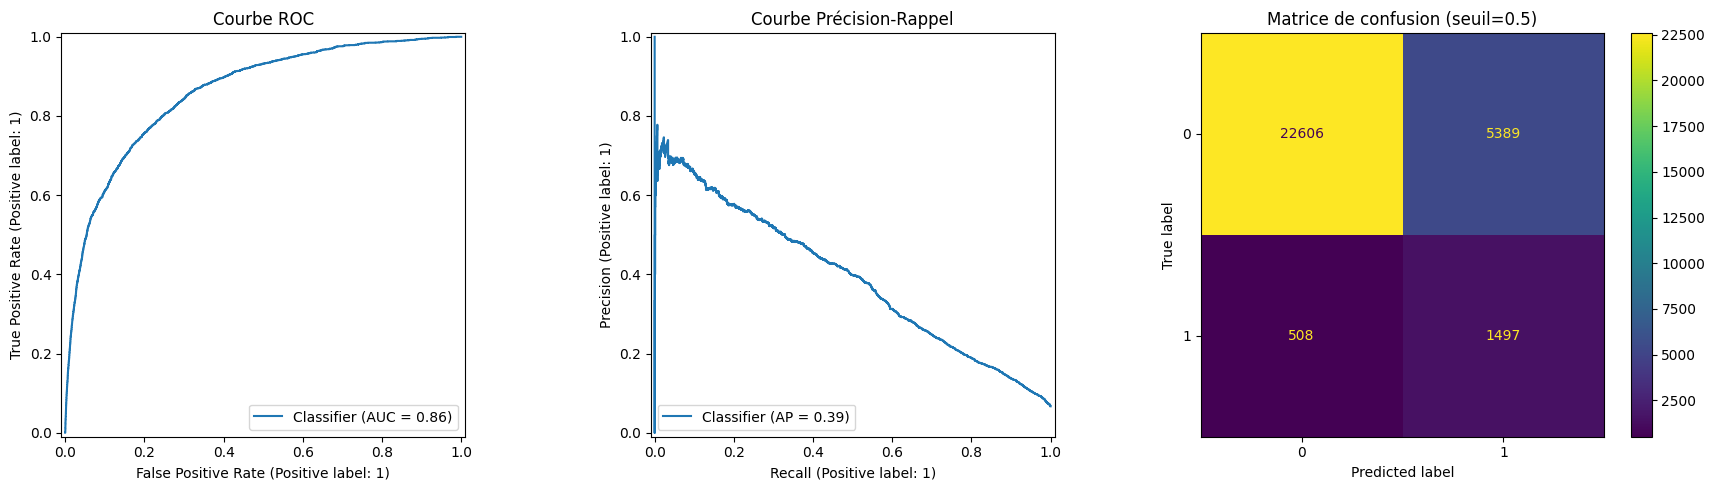

In [37]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[0])
axes[0].set_title("Courbe ROC")

PrecisionRecallDisplay.from_predictions(y_test, y_proba, ax=axes[1])
axes[1].set_title("Courbe Précision-Rappel")

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=axes[2])
axes[2].set_title("Matrice de confusion (seuil=0.5)")

fig.tight_layout()
plt.show()


### 2. Precision - Recall trade off

In [38]:
from sklearn.model_selection import cross_val_predict

In [39]:
y_scores = cross_val_predict(LR, X_train, y_train, cv=3,
                             method="decision_function")

In [40]:
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_train, y_scores)

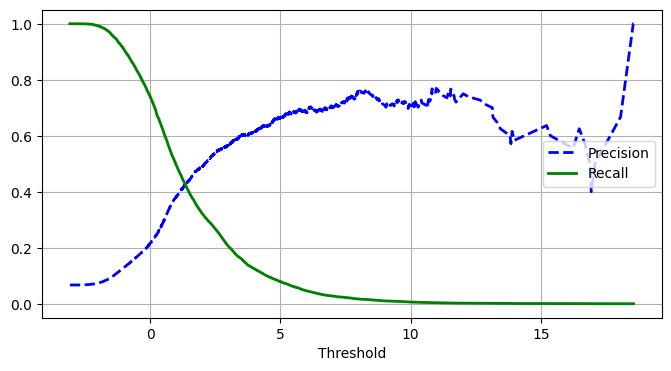

In [ ]:
plt.figure(figsize=(8, 4))  
plt.plot(thresholds, precisions[:-1], "b--", label="Precision", linewidth=2)
plt.plot(thresholds, recalls[:-1], "g-", label="Recall", linewidth=2)





plt.grid()
plt.xlabel("Threshold")
plt.legend(loc="center right")


plt.show()

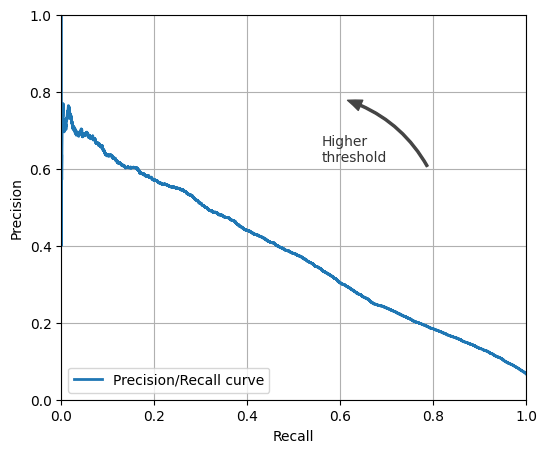

In [ ]:
import matplotlib.patches as patches  

plt.figure(figsize=(6, 5))  

plt.plot(recalls, precisions, linewidth=2, label="Precision/Recall curve")



plt.gca().add_patch(patches.FancyArrowPatch(
    (0.79, 0.60), (0.61, 0.78),
    connectionstyle="arc3,rad=.2",
    arrowstyle="Simple, tail_width=1.5, head_width=8, head_length=10",
    color="#444444"))
plt.text(0.56, 0.62, "Higher\nthreshold", color="#333333")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.axis([0, 1, 0, 1])
plt.grid()
plt.legend(loc="lower left")


plt.show()

### The ROC CURVE

In [43]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_train, y_scores)

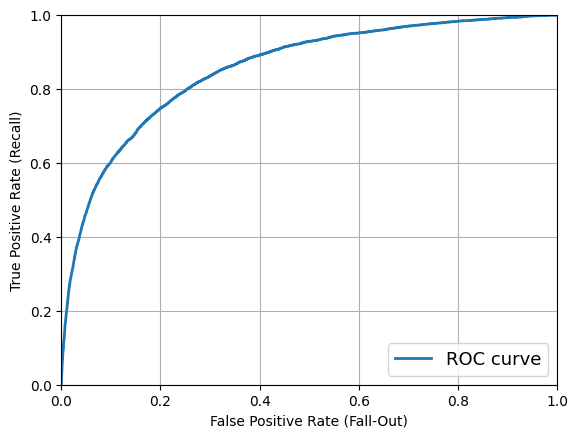

In [44]:
plt.plot(fpr, tpr, linewidth=2, label="ROC curve")
plt.xlabel('False Positive Rate (Fall-Out)')
plt.ylabel('True Positive Rate (Recall)')
plt.grid()
plt.axis([0, 1, 0, 1])
plt.legend(loc="lower right", fontsize=13)
plt.show()

In [45]:
from sklearn.metrics import roc_auc_score

roc_auc_score(y_train, y_scores)

0.8544320421033224

### 3. GridSearchCV

In [46]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline

LR = make_pipeline(
    preprocessing,
    LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')
)


In [ ]:
param_grid = [
    {
        "logisticregression__solver": ["lbfgs"],
        "logisticregression__penalty": ["l2"],
        "logisticregression__C": [0.01, 0.1, 1, 10, 100],
    },
    {
        "logisticregression__solver": ["liblinear"],   
        "logisticregression__penalty": ["l1", "l2"],
        "logisticregression__C": [0.01, 0.1, 1, 10, 100],
    },
    {
        "logisticregression__solver": ["saga"],
        "logisticregression__penalty": ["elasticnet"],  
        "logisticregression__C": [0.01, 0.1, 1, 10, 100],
        "logisticregression__l1_ratio": [0.1, 0.5, 0.9],
    },
]

grid_search = GridSearchCV(LR, param_grid, scoring="average_precision", cv=3, n_jobs=-1, verbose=3)
grid_search.fit(X_train, y_train)

Fitting 3 folds for each of 30 candidates, totalling 90 fits
[CV 2/3] END logisticregression__C=0.01, logisticregression__penalty=l2, logisticregression__solver=lbfgs;, score=0.382 total time=   0.5s
[CV 3/3] END logisticregression__C=0.01, logisticregression__penalty=l2, logisticregression__solver=lbfgs;, score=0.382 total time=   0.6s
[CV 1/3] END logisticregression__C=0.01, logisticregression__penalty=l2, logisticregression__solver=lbfgs;, score=0.380 total time=   0.6s
[CV 1/3] END logisticregression__C=0.1, logisticregression__penalty=l2, logisticregression__solver=lbfgs;, score=0.380 total time=   0.7s
[CV 2/3] END logisticregression__C=0.1, logisticregression__penalty=l2, logisticregression__solver=lbfgs;, score=0.382 total time=   0.7s
[CV 3/3] END logisticregression__C=0.1, logisticregression__penalty=l2, logisticregression__solver=lbfgs;, score=0.382 total time=   0.7s
[CV 1/3] END logisticregression__C=1, logisticregression__penalty=l2, logisticregression__solver=lbfgs;, sco

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[CV 1/3] END logisticregression__C=0.01, logisticregression__l1_ratio=0.1, logisticregression__penalty=elasticnet, logisticregression__solver=saga;, score=0.381 total time= 1.2min
[CV 1/3] END logisticregression__C=0.01, logisticregression__l1_ratio=0.5, logisticregression__penalty=elasticnet, logisticregression__solver=saga;, score=0.381 total time= 1.2min


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[CV 2/3] END logisticregression__C=0.01, logisticregression__l1_ratio=0.1, logisticregression__penalty=elasticnet, logisticregression__solver=saga;, score=0.382 total time= 1.2min
[CV 3/3] END logisticregression__C=0.01, logisticregression__l1_ratio=0.5, logisticregression__penalty=elasticnet, logisticregression__solver=saga;, score=0.382 total time=   3.3s
[CV 2/3] END logisticregression__C=0.01, logisticregression__l1_ratio=0.5, logisticregression__penalty=elasticnet, logisticregression__solver=saga;, score=0.382 total time= 1.2min


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[CV 3/3] END logisticregression__C=0.01, logisticregression__l1_ratio=0.9, logisticregression__penalty=elasticnet, logisticregression__solver=saga;, score=0.382 total time=   3.2s


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[CV 1/3] END logisticregression__C=0.01, logisticregression__l1_ratio=0.9, logisticregression__penalty=elasticnet, logisticregression__solver=saga;, score=0.381 total time=  59.6s


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[CV 2/3] END logisticregression__C=0.01, logisticregression__l1_ratio=0.9, logisticregression__penalty=elasticnet, logisticregression__solver=saga;, score=0.370 total time=  59.5s
[CV 3/3] END logisticregression__C=0.1, logisticregression__l1_ratio=0.1, logisticregression__penalty=elasticnet, logisticregression__solver=saga;, score=0.382 total time=   3.3s


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[CV 1/3] END logisticregression__C=0.1, logisticregression__l1_ratio=0.1, logisticregression__penalty=elasticnet, logisticregression__solver=saga;, score=0.381 total time= 1.0min


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[CV 2/3] END logisticregression__C=0.1, logisticregression__l1_ratio=0.1, logisticregression__penalty=elasticnet, logisticregression__solver=saga;, score=0.382 total time= 1.0min
[CV 3/3] END logisticregression__C=0.1, logisticregression__l1_ratio=0.5, logisticregression__penalty=elasticnet, logisticregression__solver=saga;, score=0.382 total time=   3.8s


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[CV 1/3] END logisticregression__C=0.1, logisticregression__l1_ratio=0.5, logisticregression__penalty=elasticnet, logisticregression__solver=saga;, score=0.381 total time= 1.0min


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[CV 2/3] END logisticregression__C=0.1, logisticregression__l1_ratio=0.5, logisticregression__penalty=elasticnet, logisticregression__solver=saga;, score=0.370 total time= 1.0min
[CV 3/3] END logisticregression__C=0.1, logisticregression__l1_ratio=0.9, logisticregression__penalty=elasticnet, logisticregression__solver=saga;, score=0.382 total time=   3.4s


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[CV 1/3] END logisticregression__C=0.1, logisticregression__l1_ratio=0.9, logisticregression__penalty=elasticnet, logisticregression__solver=saga;, score=0.381 total time= 1.0min


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[CV 2/3] END logisticregression__C=0.1, logisticregression__l1_ratio=0.9, logisticregression__penalty=elasticnet, logisticregression__solver=saga;, score=0.370 total time= 1.0min
[CV 3/3] END logisticregression__C=1, logisticregression__l1_ratio=0.1, logisticregression__penalty=elasticnet, logisticregression__solver=saga;, score=0.382 total time=   3.4s


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[CV 1/3] END logisticregression__C=1, logisticregression__l1_ratio=0.1, logisticregression__penalty=elasticnet, logisticregression__solver=saga;, score=0.381 total time= 1.3min


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[CV 2/3] END logisticregression__C=1, logisticregression__l1_ratio=0.1, logisticregression__penalty=elasticnet, logisticregression__solver=saga;, score=0.370 total time= 1.3min
[CV 3/3] END logisticregression__C=1, logisticregression__l1_ratio=0.5, logisticregression__penalty=elasticnet, logisticregression__solver=saga;, score=0.382 total time=   4.0s


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[CV 1/3] END logisticregression__C=1, logisticregression__l1_ratio=0.5, logisticregression__penalty=elasticnet, logisticregression__solver=saga;, score=0.381 total time= 1.3min


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[CV 2/3] END logisticregression__C=1, logisticregression__l1_ratio=0.5, logisticregression__penalty=elasticnet, logisticregression__solver=saga;, score=0.370 total time= 1.3min
[CV 3/3] END logisticregression__C=1, logisticregression__l1_ratio=0.9, logisticregression__penalty=elasticnet, logisticregression__solver=saga;, score=0.382 total time=   4.1s


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[CV 1/3] END logisticregression__C=1, logisticregression__l1_ratio=0.9, logisticregression__penalty=elasticnet, logisticregression__solver=saga;, score=0.381 total time= 1.2min


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[CV 2/3] END logisticregression__C=1, logisticregression__l1_ratio=0.9, logisticregression__penalty=elasticnet, logisticregression__solver=saga;, score=0.370 total time= 1.1min
[CV 3/3] END logisticregression__C=10, logisticregression__l1_ratio=0.1, logisticregression__penalty=elasticnet, logisticregression__solver=saga;, score=0.382 total time=   3.4s


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[CV 1/3] END logisticregression__C=10, logisticregression__l1_ratio=0.1, logisticregression__penalty=elasticnet, logisticregression__solver=saga;, score=0.381 total time= 1.2min


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[CV 2/3] END logisticregression__C=10, logisticregression__l1_ratio=0.1, logisticregression__penalty=elasticnet, logisticregression__solver=saga;, score=0.370 total time= 1.2min
[CV 3/3] END logisticregression__C=10, logisticregression__l1_ratio=0.5, logisticregression__penalty=elasticnet, logisticregression__solver=saga;, score=0.382 total time=   3.4s


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[CV 1/3] END logisticregression__C=10, logisticregression__l1_ratio=0.5, logisticregression__penalty=elasticnet, logisticregression__solver=saga;, score=0.381 total time= 1.2min


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[CV 2/3] END logisticregression__C=10, logisticregression__l1_ratio=0.5, logisticregression__penalty=elasticnet, logisticregression__solver=saga;, score=0.370 total time= 1.3min
[CV 3/3] END logisticregression__C=10, logisticregression__l1_ratio=0.9, logisticregression__penalty=elasticnet, logisticregression__solver=saga;, score=0.382 total time=   3.8s


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[CV 1/3] END logisticregression__C=10, logisticregression__l1_ratio=0.9, logisticregression__penalty=elasticnet, logisticregression__solver=saga;, score=0.381 total time= 1.2min


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[CV 2/3] END logisticregression__C=10, logisticregression__l1_ratio=0.9, logisticregression__penalty=elasticnet, logisticregression__solver=saga;, score=0.370 total time= 1.3min
[CV 3/3] END logisticregression__C=100, logisticregression__l1_ratio=0.1, logisticregression__penalty=elasticnet, logisticregression__solver=saga;, score=0.382 total time=   4.1s


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[CV 1/3] END logisticregression__C=100, logisticregression__l1_ratio=0.1, logisticregression__penalty=elasticnet, logisticregression__solver=saga;, score=0.381 total time= 1.2min


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[CV 2/3] END logisticregression__C=100, logisticregression__l1_ratio=0.1, logisticregression__penalty=elasticnet, logisticregression__solver=saga;, score=0.370 total time= 1.2min
[CV 3/3] END logisticregression__C=100, logisticregression__l1_ratio=0.5, logisticregression__penalty=elasticnet, logisticregression__solver=saga;, score=0.382 total time=   3.6s


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[CV 1/3] END logisticregression__C=100, logisticregression__l1_ratio=0.5, logisticregression__penalty=elasticnet, logisticregression__solver=saga;, score=0.381 total time= 1.2min


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[CV 2/3] END logisticregression__C=100, logisticregression__l1_ratio=0.5, logisticregression__penalty=elasticnet, logisticregression__solver=saga;, score=0.370 total time= 1.2min
[CV 3/3] END logisticregression__C=100, logisticregression__l1_ratio=0.9, logisticregression__penalty=elasticnet, logisticregression__solver=saga;, score=0.382 total time=   3.6s


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[CV 1/3] END logisticregression__C=100, logisticregression__l1_ratio=0.9, logisticregression__penalty=elasticnet, logisticregression__solver=saga;, score=0.381 total time=  50.8s


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[CV 2/3] END logisticregression__C=100, logisticregression__l1_ratio=0.9, logisticregression__penalty=elasticnet, logisticregression__solver=saga;, score=0.370 total time=  50.1s


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


,estimator,Pipeline(step...m_state=42))])
,param_grid,"[{'logisticregression__C': [0.01, 0.1, ...], 'logisticregression__penalty': ['l2'], 'logisticregression__solver': ['lbfgs']}, {'logisticregression__C': [0.01, 0.1, ...], 'logisticregression__penalty': ['l1', 'l2'], 'logisticregression__solver': ['liblinear']}, ...]"
,scoring,'average_precision'
,n_jobs,-1
,refit,True
,cv,3
,verbose,3
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('late_30_59', ...), ('late_60_89', ...), ...]"


In [113]:
print("Meilleurs paramètres :", grid_search.best_params_)
print("Meilleur score (PR-AUC, CV) :", grid_search.best_score_)


Meilleurs paramètres : {'logisticregression__C': 0.1, 'logisticregression__l1_ratio': 0.1, 'logisticregression__penalty': 'elasticnet', 'logisticregression__solver': 'saga'}
Meilleur score (PR-AUC, CV) : 0.38159611642789387


In [115]:
import pandas as pd

results = pd.DataFrame(grid_search.cv_results_)
results[[
    "param_logisticregression__solver",
    "param_logisticregression__penalty",
    "param_logisticregression__C",
    "param_logisticregression__l1_ratio",
    "mean_test_score",
    "std_test_score",
    "rank_test_score",
]].sort_values("rank_test_score")


,param_logisticregression__solver,param_logisticregression__penalty,param_logisticregression__C,param_logisticregression__l1_ratio,mean_test_score,std_test_score,rank_test_score
18,saga,elasticnet,0.10,0.1,0.381596,0.000503,1
16,saga,elasticnet,0.01,0.5,0.381569,0.000351,2
15,saga,elasticnet,0.01,0.1,0.381550,0.000354,3
7,liblinear,l1,0.10,NaN,0.381288,0.000588,4
11,liblinear,l1,10.00,NaN,0.381285,0.000610,5
13,liblinear,l1,100.00,NaN,0.381285,0.000610,6
9,liblinear,l1,1.00,NaN,0.381284,0.000611,7
10,liblinear,l2,1.00,NaN,0.381284,0.000610,8
6,liblinear,l2,0.01,NaN,0.381284,0.000598,9
14,liblinear,l2,100.00,NaN,0.381283,0.000609,10


### 2.1 HistGradientBoostingClassifier

In [47]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import GridSearchCV

hgb = make_pipeline(
    preprocessing,
    HistGradientBoostingClassifier(random_state=42, class_weight='balanced')
)


In [48]:
hgb.fit(X_train, y_train)

,steps,"[('columntransformer', ...), ('histgradientboostingclassifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('late_30_59', ...), ('late_60_89', ...), ...]"
,remainder,Pipeline(step...ardScaler())])
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [49]:
y_proba = hgb.predict_proba(X_test)[:, 1]
y_pred = hgb.predict(X_test)

print(f"ROC AUC                    : {roc_auc_score(y_test, y_proba):.4f}")
print(f"Average Precision (PR AUC) : {average_precision_score(y_test, y_proba):.4f}")
print()
print(classification_report(y_test, y_pred))

ROC AUC                    : 0.8681
Average Precision (PR AUC) : 0.4037

              precision    recall  f1-score   support

           0       0.98      0.80      0.88     27995
           1       0.22      0.77      0.34      2005

    accuracy                           0.80     30000
   macro avg       0.60      0.79      0.61     30000
weighted avg       0.93      0.80      0.85     30000



### 2.2 Precision/Recall Trade-off

In [50]:
y_scores = cross_val_predict(hgb, X_train, y_train, cv=3,
                             method="decision_function")

In [51]:
precisions, recalls, thresholds = precision_recall_curve(y_train, y_scores)

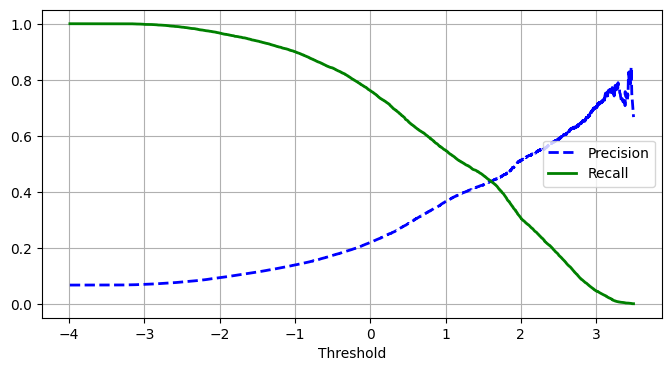

In [52]:
plt.figure(figsize=(8, 4))  
plt.plot(thresholds, precisions[:-1], "b--", label="Precision", linewidth=2)
plt.plot(thresholds, recalls[:-1], "g-", label="Recall", linewidth=2)
plt.grid()
plt.xlabel("Threshold")
plt.legend(loc="center right")

plt.show()

In [53]:
idx = (precisions[:-1] >= 0.4).argmax()
threshold_best = thresholds[idx]

print(f"Seuil     : {threshold_best:.3f}")
print(f"Precision : {precisions[idx]:.3f}")
print(f"Recall    : {recalls[idx]:.3f}")


Seuil     : 1.269
Precision : 0.400
Recall    : 0.496


### 2.3 ROC Curve

In [54]:
fpr, tpr, thresholds = roc_curve(y_train, y_scores)

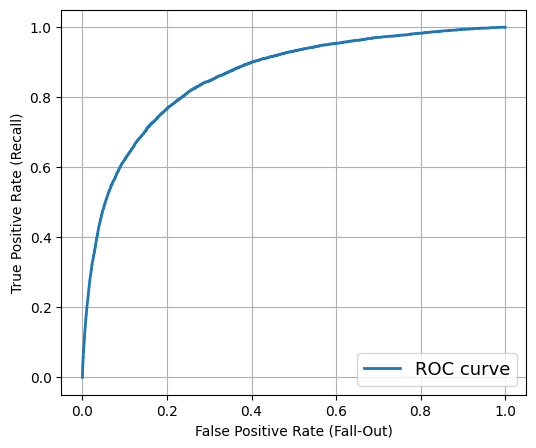

In [55]:
plt.figure(figsize=(6, 5))  # extra code – not needed, just formatting
plt.plot(fpr, tpr, linewidth=2, label="ROC curve")
plt.xlabel('False Positive Rate (Fall-Out)')
plt.ylabel('True Positive Rate (Recall)')
plt.grid()
plt.legend(loc="lower right", fontsize=13)

In [56]:
from sklearn.metrics import roc_auc_score

roc_auc_score(y_train, y_scores)

0.8610558111986104

In [57]:
y_scores_test_hgb = hgb.decision_function(X_test)
y_pred_test_hgb = (y_scores_test_hgb >= threshold_best)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_test_hgb))

              precision    recall  f1-score   support

           0       0.96      0.95      0.95     27995
           1       0.40      0.50      0.44      2005

    accuracy                           0.92     30000
   macro avg       0.68      0.72      0.70     30000
weighted avg       0.93      0.92      0.92     30000



### 3. Feeture Engineering

In [ ]:
from sklearn.preprocessing import FunctionTransformer

LATE_COLS = ['NumberOfTime30-59DaysPastDueNotWorse',
             'NumberOfTime60-89DaysPastDueNotWorse',
             'NumberOfTimes90DaysLate']

def add_features(X):
    X = X.copy()

    late = X[LATE_COLS].where(~X[LATE_COLS].isin([96, 98]))

    
    X['TotalPastDue'] = late.sum(axis=1, min_count=1)
    X['WeightedPastDue'] = (1 * late[LATE_COLS[0]]
                            + 2 * late[LATE_COLS[1]]
                            + 3 * late[LATE_COLS[2]])
    X['HasPastDue'] = (late > 0).any(axis=1).astype(int)

    
    X['MonthlyDebt'] = np.log1p(X['DebtRatio'] * X['MonthlyIncome'])

   
    X['IncomePerDependent'] = np.log1p(
        X['MonthlyIncome'] / (1 + X['NumberOfDependents']))

    # Structure du crédit
    X['NonRealEstateLines'] = (X['NumberOfOpenCreditLinesAndLoans']
                               - X['NumberRealEstateLoansOrLines'])
    X['RealEstateShare'] = (X['NumberRealEstateLoansOrLines']
                            / X['NumberOfOpenCreditLinesAndLoans'].replace(0, np.nan))
    return X

feature_engineering = FunctionTransformer(add_features)

In [59]:
LR_fe = make_pipeline(feature_engineering, preprocessing,
                      LogisticRegression(random_state=42, max_iter=1000,
                                         class_weight='balanced'))
LR_fe.fit(X_train, y_train)

y_proba = LR_fe.predict_proba(X_test)[:, 1]
print(f"ROC AUC : {roc_auc_score(y_test, y_proba):.4f}")
print(f"PR AUC  : {average_precision_score(y_test, y_proba):.4f}")

ROC AUC : 0.8633
PR AUC  : 0.3909


In [61]:
hgb_feet = make_pipeline(feature_engineering, preprocessing,
                      HistGradientBoostingClassifier(random_state=42, class_weight='balanced'))
hgb_feet.fit(X_train, y_train)

y_proba = hgb_feet.predict_proba(X_test)[:, 1]
print(f"ROC AUC : {roc_auc_score(y_test, y_proba):.4f}")
print(f"PR AUC  : {average_precision_score(y_test, y_proba):.4f}")

ROC AUC : 0.8682
PR AUC  : 0.3990


In [62]:
y_scores_test_hgb = hgb_feet.decision_function(X_test)
y_pred_test_hgb = (y_scores_test_hgb >= threshold_best)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_test_hgb))

              precision    recall  f1-score   support

           0       0.96      0.95      0.95     27995
           1       0.40      0.50      0.44      2005

    accuracy                           0.92     30000
   macro avg       0.68      0.72      0.70     30000
weighted avg       0.93      0.92      0.92     30000

